## 0. Setup & Global Config

In [ ]:
# =========================
# 0. Setup & Global Config
# =========================
import os, json, zipfile, random, warnings, time, itertools
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              precision_score, recall_score, f1_score, confusion_matrix,
                              roc_auc_score, average_precision_score)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

# ---- Master switches -------------------------------------------------
QUICK_TEST_MODE = False   # <<< set False for the full run once this passes cleanly
SEEDS_FULL = [42, 7, 123, 2024, 99]        # 5 seeds for the full run (Reviewer 2 #5)
SEEDS_QUICK = [42]                         # quick sanity run
SEEDS = SEEDS_QUICK if QUICK_TEST_MODE else SEEDS_FULL

WINDOW = 24
HORIZONS = [1, 2, 3, 4]
HORIZON_LABELS = {1: '15 min', 2: '30 min', 3: '45 min', 4: '60 min'}
INTERVAL_MINUTES = 15

EPOCHS = 5 if QUICK_TEST_MODE else 120
BATCH_SIZE = 32
PATIENCE = 3 if QUICK_TEST_MODE else 15

N_BLOCKS = 5           # number of chronological blocks per pond used for walk-forward folds
FOLD_IDS_QUICK = [0]   # only the original split, for a fast smoke test
FOLD_IDS_FULL = [0, 1, 2]  # 0 = original 70/15/15 split, 1-2 = rolling-origin walk-forward folds

RESULT_DIR = 'bab4_revised_results'
os.makedirs(RESULT_DIR, exist_ok=True)

print('TensorFlow:', tf.__version__)
print('QUICK_TEST_MODE:', QUICK_TEST_MODE)
print('SEEDS used this run:', SEEDS)
print('RESULT_DIR:', RESULT_DIR)


TensorFlow: 2.20.0
QUICK_TEST_MODE: False
SEEDS used this run: [42, 7, 123, 2024, 99]
RESULT_DIR: bab4_revised_results


## 1. Upload / Read `iot_data.csv`

In [ ]:
# =========================
# 1. Upload / read iot_data.csv
# =========================
DATA_PATH = 'iot_data.csv'

if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        print('File iot_data.csv belum ditemukan. Silakan upload iot_data.csv')
        uploaded = files.upload()
        if DATA_PATH not in uploaded:
            first_file = list(uploaded.keys())[0]
            os.rename(first_file, DATA_PATH)
            print(f'File {first_file} diganti nama menjadi {DATA_PATH}')
    except Exception as e:
        raise FileNotFoundError('Upload iot_data.csv terlebih dahulu ke runtime Colab.') from e

def read_iot_csv(path):
    try:
        df0 = pd.read_csv(path, sep=None, engine='python')
    except Exception:
        df0 = pd.read_csv(path, sep=';')
    if len(df0.columns) == 1 and ';' in df0.columns[0]:
        df0 = pd.read_csv(path, sep=';')
    return df0

raw_df = read_iot_csv(DATA_PATH)
print('Kolom awal:', raw_df.columns.tolist())
print('Shape awal:', raw_df.shape)
display(raw_df.head())


Kolom awal: ['timestamp', 'pond', 'ph', 'do', 'temp']
Shape awal: (5376, 5)


,timestamp,pond,ph,do,temp
0,01/01/26 00.00,Catfish,7.16,4.65,28.70
1,01/01/26 00.15,Catfish,7.12,4.57,28.67
2,01/01/26 00.30,Catfish,6.98,4.53,28.58
3,01/01/26 00.45,Catfish,7.07,4.56,28.62
4,01/01/26 01.00,Catfish,6.99,4.45,28.60


## 2. Clean & Normalize Data

In [ ]:
# =========================
# 2. Normalisasi kolom, timestamp, nama kolam, dan numeric columns
# =========================
df = raw_df.copy()

df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(' ', '_', regex=False)
)

rename_map = {
    'timestamp': 'timestamp', 'time': 'timestamp', 'datetime': 'timestamp', 'waktu': 'timestamp', 'tanggal': 'timestamp',
    'pond': 'pond', 'kolam': 'pond', 'pool': 'pond', 'jenis_kolam': 'pond',
    'temp': 'temp', 'temperature': 'temp', 'suhu': 'temp',
    'ph': 'ph', 'p_h': 'ph',
    'do': 'do', 'dissolved_oxygen': 'do', 'oxygen': 'do', 'dissolvedoxygen': 'do'
}
df = df.rename(columns=rename_map)

required_cols = ['timestamp', 'pond', 'temp', 'ph', 'do']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    print('Kolom setelah normalisasi:', df.columns.tolist())
    raise ValueError(f'Kolom wajib belum ditemukan: {missing}. Cek header iot_data.csv atau tambah rename_map.')

df = df[required_cols].copy()

# Bersihkan timestamp: contoh 01/01/26 00.00 -> 01/01/26 00:00
s = df['timestamp'].astype(str).str.strip()
s = s.str.replace(r'(\d{1,2})\.(\d{2})(:\d{2})?$', lambda m: m.group(0).replace('.', ':'), regex=True)

dt = pd.to_datetime(s, format='%d/%m/%y %H:%M', errors='coerce')
if dt.isna().sum() > 0:
    dt2 = pd.to_datetime(s, dayfirst=True, errors='coerce')
    dt = dt.fillna(dt2)
df['timestamp'] = dt

failed_timestamp = df['timestamp'].isna().sum()
print('Jumlah timestamp gagal parse:', failed_timestamp)
if failed_timestamp > 0:
    display(df[df['timestamp'].isna()].head(20))
    raise ValueError('Masih ada timestamp yang gagal dibaca. Cek format tanggal pada baris yang ditampilkan.')

def to_numeric_clean(series):
    return pd.to_numeric(series.astype(str).str.strip().str.replace(',', '.', regex=False), errors='coerce')

df['temp'] = to_numeric_clean(df['temp'])
df['ph'] = to_numeric_clean(df['ph'])
df['do'] = to_numeric_clean(df['do'])

# NOTE: nama kolam DIPERTAHANKAN dalam Bahasa Inggris (Catfish/Gourami/Nilem/Tilapia)
# agar konsisten dengan manuskrip dan tidak perlu mapping balik saat menulis Bab 4/paper.
df['pond'] = df['pond'].astype(str).str.strip()

df = df.sort_values(['pond', 'timestamp']).reset_index(drop=True)

print('Kolom setelah normalisasi:', df.columns.tolist())
print('Nama kolam:', sorted(df['pond'].unique().tolist()))
print('Shape:', df.shape)

# Tampilkan rentang kalender tiap pond -- PENTING: pond-pond ini TIDAK diobservasi
# paralel, melainkan berurutan secara waktu. Ini perlu disebutkan eksplisit di manuskrip.
calendar_span = df.groupby('pond')['timestamp'].agg(['min', 'max'])
print('\nRentang kalender tiap pond (pond diobservasi berurutan, bukan paralel):')
display(calendar_span)
calendar_span.to_csv(f'{RESULT_DIR}/pond_calendar_span.csv')

display(df.head())


Jumlah timestamp gagal parse: 0
Kolom setelah normalisasi: ['timestamp', 'pond', 'temp', 'ph', 'do']
Nama kolam: ['Catfish', 'Gourami', 'Nilem', 'Tilapia']
Shape: (5376, 5)

Rentang kalender tiap pond (pond diobservasi berurutan, bukan paralel):


,min,max
pond,,
Catfish,2026-01-01,2026-01-14 23:45:00
Gourami,2026-01-15,2026-01-28 23:45:00
Nilem,2026-02-12,2026-02-25 23:45:00
Tilapia,2026-01-29,2026-02-11 23:45:00


,timestamp,pond,temp,ph,do
0,2026-01-01 00:00:00,Catfish,28.70,7.16,4.65
1,2026-01-01 00:15:00,Catfish,28.67,7.12,4.57
2,2026-01-01 00:30:00,Catfish,28.58,6.98,4.53
3,2026-01-01 00:45:00,Catfish,28.62,7.07,4.56
4,2026-01-01 01:00:00,Catfish,28.60,6.99,4.45


## 3. Data Readiness Checks

In [ ]:
# =========================
# 3. Data readiness checks dan physical range filtering
# =========================
readiness_summary = []

n_initial = len(df)
readiness_summary.append({'step': 'initial_rows', 'rows': n_initial})

dup_count = df.duplicated(subset=['pond', 'timestamp']).sum()
readiness_summary.append({'step': 'duplicated_pond_timestamp', 'rows': int(dup_count)})
df = df.drop_duplicates(subset=['pond', 'timestamp'], keep='first').copy()

invalid_mask = (
    (df['temp'] < 0) | (df['temp'] > 50) |
    (df['ph'] < 0) | (df['ph'] > 14) |
    (df['do'] < 0) | (df['do'] > 20) |
    df[['temp', 'ph', 'do']].isna().any(axis=1)
)
readiness_summary.append({'step': 'invalid_or_missing_sensor_rows', 'rows': int(invalid_mask.sum())})
df_clean = df.loc[~invalid_mask].copy().reset_index(drop=True)
readiness_summary.append({'step': 'final_clean_rows', 'rows': len(df_clean)})

interval_summary = []
for pond, g in df_clean.groupby('pond'):
    g = g.sort_values('timestamp')
    diffs = g['timestamp'].diff().dropna().dt.total_seconds() / 60
    interval_summary.append({
        'pond': pond,
        'observations': len(g),
        'start_time': g['timestamp'].min(),
        'end_time': g['timestamp'].max(),
        'median_interval_minutes': diffs.median() if len(diffs) > 0 else np.nan,
        'non_15min_intervals': int((diffs != 15).sum()) if len(diffs) > 0 else 0
    })

readiness_df = pd.DataFrame(readiness_summary)
interval_df = pd.DataFrame(interval_summary)
readiness_df.to_csv(f'{RESULT_DIR}/data_readiness_summary.csv', index=False)
interval_df.to_csv(f'{RESULT_DIR}/interval_summary.csv', index=False)

df = df_clean
print('Data readiness summary')
display(readiness_df)
print('Interval summary')
display(interval_df)


Data readiness summary


,step,rows
0,initial_rows,5376
1,duplicated_pond_timestamp,0
2,invalid_or_missing_sensor_rows,0
3,final_clean_rows,5376


Interval summary


,pond,observations,start_time,end_time,median_interval_minutes,non_15min_intervals
0,Catfish,1344,2026-01-01,2026-01-14 23:45:00,15.0,0
1,Gourami,1344,2026-01-15,2026-01-28 23:45:00,15.0,0
2,Nilem,1344,2026-02-12,2026-02-25 23:45:00,15.0,0
3,Tilapia,1344,2026-01-29,2026-02-11 23:45:00,15.0,0


## 4. Temporal Assessment (Suitability / Excursion Scoring)

In [ ]:
# =========================
# 4. Rentang acuan dan assessment temporal
# =========================
# Rentang species-specific TIDAK diubah dari manuskrip -- hanya key pond disamakan
# dengan nama Inggris yang dipakai konsisten di seluruh notebook & manuskrip.
RANGES = {
    'Catfish': {'temp_opt': (25, 30), 'temp_ops': (23, 32), 'ph_opt': (7.0, 8.5), 'ph_ops': (6.5, 9.0), 'do_opt': 3.0, 'do_ops': 2.0},
    'Gourami': {'temp_opt': (25, 30), 'temp_ops': (23, 32), 'ph_opt': (6.5, 8.5), 'ph_ops': (6.0, 9.0), 'do_opt': 5.0, 'do_ops': 4.0},
    'Nilem':   {'temp_opt': (26, 29), 'temp_ops': (24, 31), 'ph_opt': (6.5, 8.0), 'ph_ops': (6.0, 8.5), 'do_opt': 5.0, 'do_ops': 4.0},
    'Tilapia': {'temp_opt': (25, 30), 'temp_ops': (23, 32), 'ph_opt': (6.5, 8.5), 'ph_ops': (6.0, 9.0), 'do_opt': 5.0, 'do_ops': 4.0},
}

unknown_ponds = sorted(set(df['pond'].unique()) - set(RANGES.keys()))
if unknown_ponds:
    raise ValueError(f'Nama kolam belum ada di RANGES: {unknown_ponds}. Tambahkan mapping pond atau RANGES.')

def score_interval(value, opt_range, ops_range):
    opt_low, opt_high = opt_range
    ops_low, ops_high = ops_range
    if pd.isna(value):
        return np.nan
    if opt_low <= value <= opt_high:
        return 3
    if ops_low <= value <= ops_high:
        return 2
    return 1

def score_do(value, opt_min, ops_min):
    if pd.isna(value):
        return np.nan
    if value >= opt_min:
        return 3
    if value >= ops_min:
        return 2
    return 1

df['temp_score'] = np.nan
df['ph_score'] = np.nan
df['do_score'] = np.nan
df['do_ops_thr'] = np.nan
df['do_opt_thr'] = np.nan

for pond, idx in df.groupby('pond').groups.items():
    r = RANGES[pond]
    df.loc[idx, 'temp_score'] = df.loc[idx, 'temp'].apply(lambda v: score_interval(v, r['temp_opt'], r['temp_ops']))
    df.loc[idx, 'ph_score'] = df.loc[idx, 'ph'].apply(lambda v: score_interval(v, r['ph_opt'], r['ph_ops']))
    df.loc[idx, 'do_score'] = df.loc[idx, 'do'].apply(lambda v: score_do(v, r['do_opt'], r['do_ops']))
    df.loc[idx, 'do_ops_thr'] = r['do_ops']
    df.loc[idx, 'do_opt_thr'] = r['do_opt']

df['pond_score'] = df[['temp_score', 'ph_score', 'do_score']].mean(axis=1)

# Fitur assessment DO
df['do_excursion_flag'] = (df['do'] < df['do_ops_thr']).astype(int)
df['do_warning_flag'] = ((df['do'] < df['do_opt_thr']) & (df['do'] >= df['do_ops_thr'])).astype(int)
df['do_gap_ops'] = df['do'] - df['do_ops_thr']
df['do_gap_opt'] = df['do'] - df['do_opt_thr']

df['do_excursion_duration_steps'] = 0
for pond, g in df.groupby('pond'):
    duration = []
    cur = 0
    for flag in g['do_excursion_flag'].astype(int).values:
        cur = cur + 1 if flag == 1 else 0
        duration.append(cur)
    df.loc[g.index, 'do_excursion_duration_steps'] = duration

df['do_excursion_duration_minutes'] = df['do_excursion_duration_steps'] * INTERVAL_MINUTES

df.to_csv(f'{RESULT_DIR}/processed_iot_dataset_with_assessment.csv', index=False)

print('Assessment columns created:')
print([c for c in df.columns if 'score' in c or 'do_' in c])
display(df.head())


Assessment columns created:
['temp_score', 'ph_score', 'do_score', 'do_ops_thr', 'do_opt_thr', 'pond_score', 'do_excursion_flag', 'do_warning_flag', 'do_gap_ops', 'do_gap_opt', 'do_excursion_duration_steps', 'do_excursion_duration_minutes']


,timestamp,pond,temp,ph,do,temp_score,ph_score,do_score,do_ops_thr,do_opt_thr,pond_score,do_excursion_flag,do_warning_flag,do_gap_ops,do_gap_opt,do_excursion_duration_steps,do_excursion_duration_minutes
0,2026-01-01 00:00:00,Catfish,28.70,7.16,4.65,3.0,3.0,3.0,2.0,3.0,3.000000,0,0,2.65,1.65,0,0
1,2026-01-01 00:15:00,Catfish,28.67,7.12,4.57,3.0,3.0,3.0,2.0,3.0,3.000000,0,0,2.57,1.57,0,0
2,2026-01-01 00:30:00,Catfish,28.58,6.98,4.53,3.0,2.0,3.0,2.0,3.0,2.666667,0,0,2.53,1.53,0,0
3,2026-01-01 00:45:00,Catfish,28.62,7.07,4.56,3.0,3.0,3.0,2.0,3.0,3.000000,0,0,2.56,1.56,0,0
4,2026-01-01 01:00:00,Catfish,28.60,6.99,4.45,3.0,2.0,3.0,2.0,3.0,2.666667,0,0,2.45,1.45,0,0


## 5. Assessment Summaries & Class-Prevalence Reporting (Reviewer 2 #6)

In [ ]:
# =========================
# 5. Assessment result summaries + class-prevalence reporting (Reviewer 2 #6)
# =========================
suitability_summary = df.groupby('pond').agg(
    obs=('do', 'size'),
    temp_score=('temp_score', 'mean'),
    ph_score=('ph_score', 'mean'),
    do_score=('do_score', 'mean'),
    pond_score=('pond_score', 'mean'),
    mean_temp=('temp', 'mean'),
    mean_ph=('ph', 'mean'),
    mean_do=('do', 'mean')
).reset_index()
suitability_summary.to_csv(f'{RESULT_DIR}/assessment_suitability_summary.csv', index=False)

def excursion_events_for_series(flags):
    events = []
    start = None
    length = 0
    vals = list(flags.astype(int).values)
    for i, flag in enumerate(vals):
        if flag == 1 and start is None:
            start = i
            length = 1
        elif flag == 1:
            length += 1
        elif flag == 0 and start is not None:
            events.append(length)
            start = None
            length = 0
    if start is not None:
        events.append(length)
    return events

exc_rows = []
for pond, g in df.groupby('pond'):
    events = excursion_events_for_series(g['do_excursion_flag'])
    durations = [e * INTERVAL_MINUTES / 60 for e in events]
    exc_rows.append({
        'pond': pond,
        'event_count': len(events),
        'total_duration_hours': float(np.sum(durations)) if durations else 0.0,
        'max_duration_hours': float(np.max(durations)) if durations else 0.0,
        'excursion_rate': float(g['do_excursion_flag'].mean()),
        # NEW -- explicit class-prevalence numbers requested by Reviewer 2 #6
        'n_timestamps': len(g),
        'n_low_do_timestamps': int(g['do_excursion_flag'].sum()),
        'positive_prevalence_pct': round(100 * g['do_excursion_flag'].mean(), 2),
    })
excursion_summary = pd.DataFrame(exc_rows)
excursion_summary.to_csv(f'{RESULT_DIR}/assessment_excursion_do_summary_with_prevalence.csv', index=False)

stability_summary = df.groupby('pond').agg(
    temp_mean=('temp', 'mean'), temp_sd=('temp', 'std'),
    ph_mean=('ph', 'mean'), ph_sd=('ph', 'std'),
    do_mean=('do', 'mean'), do_sd=('do', 'std')
).reset_index()
for param in ['temp', 'ph', 'do']:
    stability_summary[f'{param}_cv'] = stability_summary[f'{param}_sd'] / stability_summary[f'{param}_mean']
stability_summary.to_csv(f'{RESULT_DIR}/assessment_temporal_stability_summary.csv', index=False)

print('Suitability summary')
display(suitability_summary)
print('Excursion / DO event summary (with class prevalence -- Reviewer 2 #6)')
display(excursion_summary)
print('Stability summary')
display(stability_summary)


Suitability summary


,pond,obs,temp_score,ph_score,do_score,pond_score,mean_temp,mean_ph,mean_do
0,Catfish,1344,2.999256,2.861607,2.988839,2.949901,29.177530,7.097068,4.708899
1,Gourami,1344,2.848958,3.000000,2.202381,2.683780,28.574263,7.575298,4.760327
2,Nilem,1344,2.753720,3.000000,2.508929,2.754216,27.653891,7.463973,5.310015
3,Tilapia,1344,2.781250,3.000000,2.379464,2.720238,28.761257,7.769903,5.035997


Excursion / DO event summary (with class prevalence -- Reviewer 2 #6)


,pond,event_count,total_duration_hours,max_duration_hours,excursion_rate,n_timestamps,n_low_do_timestamps,positive_prevalence_pct
0,Catfish,0,0.00,0.00,0.000000,1344,0,0.00
1,Gourami,82,78.25,11.00,0.232887,1344,313,23.29
2,Nilem,45,26.00,7.25,0.077381,1344,104,7.74
3,Tilapia,73,44.00,9.25,0.130952,1344,176,13.10


Stability summary


,pond,temp_mean,temp_sd,ph_mean,ph_sd,do_mean,do_sd,temp_cv,ph_cv,do_cv
0,Catfish,29.177530,0.440067,7.097068,0.094645,4.708899,0.498965,0.015082,0.013336,0.105962
1,Gourami,28.574263,1.200902,7.575298,0.156247,4.760327,0.935110,0.042027,0.020626,0.196438
2,Nilem,27.653891,1.200695,7.463973,0.156759,5.310015,0.955682,0.043419,0.021002,0.179977
3,Tilapia,28.761257,1.220513,7.769903,0.158013,5.035997,0.950137,0.042436,0.020337,0.188669


## 6. Feature Engineering + Explicit Formula Export (Reviewer 2 #7)

In [ ]:
# =========================
# 6. Feature engineering: temporal, suitability, excursion, stability
# =========================
df['hour'] = df['timestamp'].dt.hour + df['timestamp'].dt.minute / 60.0
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_index'] = (df['timestamp'] - df.groupby('pond')['timestamp'].transform('min')).dt.total_seconds() / (24 * 3600)

pond_dummies = pd.get_dummies(df['pond'], prefix='pond', dtype=int)
df = pd.concat([df, pond_dummies], axis=1)
POND_FEATURES = pond_dummies.columns.tolist()

LAGS = [1, 2, 3, 4, 8, 12, 24]
WINDOWS = [4, 8, 24]

new_cols = {}
for pond, g in df.groupby('pond'):
    idx = g.index
    for col in ['temp', 'ph', 'do']:
        for lag in LAGS:
            new_cols[f'{col}_lag{lag}'] = new_cols.get(f'{col}_lag{lag}', pd.Series(index=df.index, dtype=float))
            new_cols[f'{col}_lag{lag}'].loc[idx] = g[col].shift(lag)
        for win in WINDOWS:
            for suffix, fn in [('roll_mean', 'mean'), ('roll_sd', 'std'), ('roll_min', 'min'), ('roll_max', 'max')]:
                key = f'{col}_{suffix}{win}'
                new_cols[key] = new_cols.get(key, pd.Series(index=df.index, dtype=float))
                new_cols[key].loc[idx] = getattr(g[col].rolling(win, min_periods=win), fn)()
            cv_key = f'{col}_roll_cv{win}'
            new_cols[cv_key] = new_cols.get(cv_key, pd.Series(index=df.index, dtype=float))
            new_cols[cv_key].loc[idx] = new_cols[f'{col}_roll_sd{win}'].loc[idx] / new_cols[f'{col}_roll_mean{win}'].loc[idx]
    for col in ['temp_score', 'ph_score', 'do_score', 'pond_score', 'do_excursion_flag', 'do_warning_flag']:
        for win in WINDOWS:
            mean_key = f'{col}_roll_mean{win}'
            sum_key = f'{col}_roll_sum{win}'
            new_cols[mean_key] = new_cols.get(mean_key, pd.Series(index=df.index, dtype=float))
            new_cols[sum_key] = new_cols.get(sum_key, pd.Series(index=df.index, dtype=float))
            new_cols[mean_key].loc[idx] = g[col].rolling(win, min_periods=win).mean()
            new_cols[sum_key].loc[idx] = g[col].rolling(win, min_periods=win).sum()

df = pd.concat([df, pd.DataFrame(new_cols)], axis=1)

BASE_FEATURES = ['temp', 'ph', 'do', 'hour_sin', 'hour_cos', 'day_index'] + POND_FEATURES

# -------------------------------------------------------------------
# FIXED (previously buggy): TEMPORAL_FEATURES is now built EXPLICITLY from
# the sensor lag/rolling columns we actually generated, instead of guessing
# via string matching. The old regex-based filter --
#   c.split('_')[0] in ['temp','ph','do']
# -- incorrectly matched columns like "temp_score_roll_mean4" and
# "do_excursion_flag_roll_mean8" too, because their FIRST token also happens
# to be "temp"/"do". That silently leaked 15 suitability/excursion-derived
# columns into every "Raw" and "SOTA baseline" feature set, contaminating
# the ablation study's control group. This explicit construction cannot
# make that mistake because it only ever appends the exact names created
# in the lag/rolling loop above.
# -------------------------------------------------------------------
TEMPORAL_FEATURES = []
for _col in ['temp', 'ph', 'do']:
    for _lag in LAGS:
        TEMPORAL_FEATURES.append(f'{_col}_lag{_lag}')
    for _win in WINDOWS:
        TEMPORAL_FEATURES.append(f'{_col}_roll_mean{_win}')
        TEMPORAL_FEATURES.append(f'{_col}_roll_min{_win}')
        TEMPORAL_FEATURES.append(f'{_col}_roll_max{_win}')
_leaked_check = [c for c in TEMPORAL_FEATURES if 'score' in c or 'flag' in c]
assert len(_leaked_check) == 0, f'TEMPORAL_FEATURES leaked non-sensor columns: {_leaked_check}'

SUITABILITY_FEATURES = ['temp_score', 'ph_score', 'do_score', 'pond_score', 'do_gap_ops', 'do_gap_opt'] + \
    [c for c in df.columns if any(c.startswith(p) for p in ['temp_score_roll', 'ph_score_roll', 'do_score_roll', 'pond_score_roll'])]

EXCURSION_FEATURES = ['do_excursion_flag', 'do_warning_flag', 'do_excursion_duration_steps', 'do_excursion_duration_minutes'] + \
    [c for c in df.columns if c.startswith('do_excursion_flag_roll') or c.startswith('do_warning_flag_roll')]

STABILITY_FEATURES = [c for c in df.columns if any(c.endswith(f'_roll_sd{w}') or c.endswith(f'_roll_cv{w}') for w in WINDOWS)]

def uniq(seq):
    out = []
    for x in seq:
        if x not in out:
            out.append(x)
    return out

BASE_FEATURES = uniq(BASE_FEATURES)
TEMPORAL_FEATURES = uniq(TEMPORAL_FEATURES)
SUITABILITY_FEATURES = uniq(SUITABILITY_FEATURES)
EXCURSION_FEATURES = uniq(EXCURSION_FEATURES)
STABILITY_FEATURES = uniq(STABILITY_FEATURES)

feature_groups = {
    'BASE_FEATURES': BASE_FEATURES,
    'TEMPORAL_FEATURES': TEMPORAL_FEATURES,
    'SUITABILITY_FEATURES': SUITABILITY_FEATURES,
    'EXCURSION_FEATURES': EXCURSION_FEATURES,
    'STABILITY_FEATURES': STABILITY_FEATURES,
}
with open(f'{RESULT_DIR}/feature_groups.json', 'w') as f:
    json.dump(feature_groups, f, indent=2)

df.to_csv(f'{RESULT_DIR}/processed_iot_dataset_with_features.csv', index=False)

for name, feats in feature_groups.items():
    print(name, len(feats))

# -------------------------------------------------------------------
# NEW: explicit, human-readable formulas for every engineered feature
# group, exported for the manuscript's reproducibility section and
# for the response letter to Reviewer 2 #7.
# -------------------------------------------------------------------
feature_engineering_config = {
    "window_and_horizons": {
        "sequence_window_steps": WINDOW,
        "sequence_window_minutes": WINDOW * INTERVAL_MINUTES,
        "forecast_horizons_steps": HORIZONS,
        "forecast_horizons_minutes": [h * INTERVAL_MINUTES for h in HORIZONS],
        "sampling_interval_minutes": INTERVAL_MINUTES,
    },
    "suitability_score_formula": {
        "temp_score / ph_score": "3 if value in optimal_range; 2 if value in operational_range (but not optimal); 1 otherwise",
        "do_score": "3 if do >= do_opt_threshold; 2 if do_ops_threshold <= do < do_opt_threshold; 1 if do < do_ops_threshold",
        "pond_score": "mean(temp_score, ph_score, do_score)",
        "do_gap_ops": "do - do_ops_threshold  (negative => below operational limit)",
        "do_gap_opt": "do - do_opt_threshold  (negative => below optimal limit)",
        "rolling suitability features": "rolling mean/sum of the above scores over the trailing W in {4,8,24} timesteps, min_periods=W (no forward-looking values; first W-1 rows of each pond series are NaN and dropped)",
    },
    "excursion_formula": {
        "do_excursion_flag": "1 if do < do_ops_threshold else 0",
        "do_warning_flag": "1 if do_ops_threshold <= do < do_opt_threshold else 0",
        "do_excursion_duration_steps": "running count of consecutive prior timesteps (including current) with do_excursion_flag == 1; resets to 0 on the first non-excursion step",
        "do_excursion_duration_minutes": "do_excursion_duration_steps * 15",
        "rolling excursion features": "rolling mean/sum of do_excursion_flag / do_warning_flag over trailing W in {4,8,24} timesteps, min_periods=W",
    },
    "stability_formula": {
        "{var}_roll_sd{W}": "rolling standard deviation of temp/ph/do over the trailing W in {4,8,24} timesteps, min_periods=W",
        "{var}_roll_cv{W}": "{var}_roll_sd{W} / {var}_roll_mean{W}  (coefficient of variation)",
    },
    "temporal_features_formula": {
        "{var}_lag{L}": "value of temp/ph/do exactly L timesteps ago, L in {1,2,3,4,8,12,24}",
        "{var}_roll_mean{W}/_roll_min{W}/_roll_max{W}": "rolling statistic of temp/ph/do over trailing W in {4,8,24} timesteps, min_periods=W",
        "hour_sin / hour_cos": "sin/cos encoding of time-of-day, period = 24h",
        "day_index": "elapsed days since the first observation of that pond's monitoring period",
        "pond_* (one-hot)": "one-hot indicator of pond identity",
    },
    "no_future_leakage_guarantee": (
        "All lag and rolling-window operations use pandas .shift()/.rolling() in the default "
        "(backward-looking, non-centered) mode with min_periods=window, computed independently "
        "per pond after chronological sorting. A feature at row t therefore uses only "
        "observations at or before t. This is verified programmatically in the "
        "'Leakage / temporal-alignment audit' cell below, which recomputes a random sample of "
        "features directly from the raw series and checks for exact agreement."
    ),
    "boundary_sample_handling": (
        "Any row where a lag/rolling feature is undefined (the first max(LAGS, WINDOWS)-1 "
        "timesteps of each pond) is NaN. A training/eval sequence of length WINDOW is discarded "
        "entirely if it contains ANY NaN across its window or in its target horizons "
        "(see make_sequences()). This is why the number of valid sequences per pond "
        "(~1,293) is slightly lower than the naive count 1344-WINDOW-max(HORIZONS)+1=1317 "
        "reported in the previous manuscript draft; the revised manuscript text should use "
        "the corrected count."
    ),
}
with open(f'{RESULT_DIR}/feature_engineering_config.json', 'w') as f:
    json.dump(feature_engineering_config, f, indent=2)

print('\nSaved feature_engineering_config.json with explicit formulas for every feature group.')


BASE_FEATURES 10
TEMPORAL_FEATURES 48
SUITABILITY_FEATURES 30
EXCURSION_FEATURES 16
STABILITY_FEATURES 18

Saved feature_engineering_config.json with explicit formulas for every feature group.


## 7. Sequence Builder + Rolling-Origin Walk-Forward Folds (Reviewer 2 #4)

In [ ]:
# =========================
# 7. Sequence builder and evaluation folds
#    (original 70/15/15 split + rolling-origin walk-forward folds)
# =========================
def make_sequences(data, feature_cols, window=WINDOW, horizons=HORIZONS):
    Xs, Ys, metas, last_dos = [], [], [], []
    max_h = max(horizons)
    for pond, g in data.groupby('pond'):
        g = g.sort_values('timestamp').reset_index(drop=True)
        feature_values = g[feature_cols].values.astype(float)
        do_values = g['do'].values.astype(float)
        timestamps = g['timestamp'].values
        ops_thr = float(RANGES[pond]['do_ops'])
        for end in range(window - 1, len(g) - max_h):
            start = end - window + 1
            X = feature_values[start:end + 1]
            y = np.array([do_values[end + h] for h in horizons], dtype=float)
            if np.isnan(X).any() or np.isnan(y).any():
                continue
            Xs.append(X)
            Ys.append(y)
            last_dos.append(do_values[end])
            metas.append({
                'pond': pond,
                'end_timestamp': pd.Timestamp(timestamps[end]),
                'do_ops_thr': ops_thr,
                'last_do': do_values[end],
            })
    X = np.array(Xs, dtype=float)
    Y = np.array(Ys, dtype=float)
    meta = pd.DataFrame(metas)
    last_do = np.array(last_dos, dtype=float)
    return X, Y, meta, last_do

# ---------------------------------------------------------------------
# IMPORTANT SIMPLIFICATION (verified against the real dataset before
# relying on it): every feature set in FEATURE_SETS below shares the same
# NaN warm-up boundary, because TEMPORAL_FEATURES alone already requires a
# 24-step lag/rolling window -- the same requirement suitability/excursion/
# stability features impose. As a result, make_sequences() returns EXACTLY
# the same (pond, end_timestamp) rows, in the same order, no matter which
# feature_cols is passed in (checked with meta_raw.equals(meta_full) on the
# actual iot_data.csv -- both give 5,172 rows, identical row-for-row). We
# therefore compute the split/fold POSITION INDICES only once and reuse
# them for every scenario's X/Y array.
# ---------------------------------------------------------------------

def original_chronological_split(meta, train_ratio=0.70, val_ratio=0.15):
    """The single 70/15/15 chronological split used in the previous manuscript
    draft. Kept as fold 0 so results remain comparable to earlier numbers."""
    train_idx, val_idx, test_idx = [], [], []
    for pond, g in meta.groupby('pond'):
        idx = g.sort_values('end_timestamp').index.to_numpy()
        n = len(idx)
        n_train = int(np.floor(train_ratio * n))
        n_val = int(np.floor(val_ratio * n))
        train_idx.extend(idx[:n_train])
        val_idx.extend(idx[n_train:n_train + n_val])
        test_idx.extend(idx[n_train + n_val:])
    return np.array(train_idx), np.array(val_idx), np.array(test_idx)

def make_walkforward_folds(meta, n_blocks=N_BLOCKS):
    """NEW -- rolling-origin (walk-forward) folds requested by Reviewer 2 #4.
    Each pond's sequences are cut chronologically into `n_blocks` equal-size,
    non-overlapping blocks. Each fold trains on an EXPANDING prefix of
    blocks, validates on the next block, and tests on the block after that,
    so every fold's test period is a genuinely different, later slice of
    the calendar than fold 0's test period, per pond."""
    meta = meta.copy()
    meta['block'] = -1
    for pond, g in meta.groupby('pond'):
        order = g.sort_values('end_timestamp').index
        n = len(order)
        block_id = np.minimum((np.floor(np.arange(n) / n * n_blocks)).astype(int), n_blocks - 1)
        meta.loc[order, 'block'] = block_id

    fold_specs = []
    for k in range(n_blocks - 2):
        train_blocks = list(range(0, k + 2))
        val_block = k + 2
        test_block = k + 3
        if test_block >= n_blocks:
            break
        fold_specs.append({'fold': k + 1, 'train_blocks': train_blocks, 'val_block': val_block, 'test_block': test_block})
    return meta, fold_specs

def scale_3d(X_train, X_val, X_test):
    scaler = StandardScaler()
    n_train, t, f = X_train.shape
    scaler.fit(X_train.reshape(-1, f))
    def transform(X):
        n, t, f = X.shape
        return scaler.transform(X.reshape(-1, f)).reshape(n, t, f)
    return transform(X_train), transform(X_val), transform(X_test), scaler

# Feature sets -- Raw_GRU and Full_Assessment_GRU now mirror their LSTM
# counterparts EXACTLY, fixing the confounded comparison (Reviewer 2 #2).
FEATURE_SETS = {
    'Raw_LSTM': BASE_FEATURES + TEMPORAL_FEATURES,
    'Raw_GRU': BASE_FEATURES + TEMPORAL_FEATURES,                                            # NEW -- was missing before
    'LSTM_Suitability': BASE_FEATURES + TEMPORAL_FEATURES + SUITABILITY_FEATURES,
    'LSTM_Excursion': BASE_FEATURES + TEMPORAL_FEATURES + EXCURSION_FEATURES,
    'LSTM_Stability': BASE_FEATURES + TEMPORAL_FEATURES + STABILITY_FEATURES,
    'Full_Assessment_Guided_LSTM': BASE_FEATURES + TEMPORAL_FEATURES + SUITABILITY_FEATURES + EXCURSION_FEATURES + STABILITY_FEATURES,
    'Full_Assessment_GRU': BASE_FEATURES + TEMPORAL_FEATURES + SUITABILITY_FEATURES + EXCURSION_FEATURES + STABILITY_FEATURES,  # RENAMED from GRU_Baseline
    # NEW -- reimplemented 2024+ literature-style baselines (Reviewer 1 #8,
    # Reviewer 2 #1), trained on the SAME Raw feature set as Raw_LSTM/Raw_GRU
    # for a controlled comparison.
    'GRU_NBeats_lite': BASE_FEATURES + TEMPORAL_FEATURES,
    'CNN_GRU_Attention': BASE_FEATURES + TEMPORAL_FEATURES,
}
FEATURE_SETS = {k: uniq(v) for k, v in FEATURE_SETS.items()}

MODEL_FAMILY = {
    'Raw_LSTM': 'lstm', 'LSTM_Suitability': 'lstm', 'LSTM_Excursion': 'lstm',
    'LSTM_Stability': 'lstm', 'Full_Assessment_Guided_LSTM': 'lstm',
    'Raw_GRU': 'gru', 'Full_Assessment_GRU': 'gru',
    'GRU_NBeats_lite': 'gru_nbeats', 'CNN_GRU_Attention': 'cnn_gru_attention',
}

# Build sequences once (any feature set gives identical meta -- see note above)
X_full, Y_full, meta_full, last_do_full = make_sequences(df, FEATURE_SETS['Full_Assessment_GRU'])
orig_train_idx, orig_val_idx, orig_test_idx = original_chronological_split(meta_full)
meta_with_blocks, fold_specs = make_walkforward_folds(meta_full, n_blocks=N_BLOCKS)

# Precompute the (train_idx, val_idx, test_idx) position arrays for every
# fold ONCE. These same position arrays are valid for every scenario's own
# X/Y array because all scenarios share the identical row order (verified above).
FOLD_INDEX_MAP = {0: (orig_train_idx, orig_val_idx, orig_test_idx)}
for spec in fold_specs:
    tr = meta_with_blocks.index[meta_with_blocks['block'].isin(spec['train_blocks'])].to_numpy()
    va = meta_with_blocks.index[meta_with_blocks['block'] == spec['val_block']].to_numpy()
    te = meta_with_blocks.index[meta_with_blocks['block'] == spec['test_block']].to_numpy()
    FOLD_INDEX_MAP[spec['fold']] = (tr, va, te)

split_summary = []
for fold_id, (tr, va, te) in FOLD_INDEX_MAP.items():
    for split_name, idxs in [('train', tr), ('validation', va), ('test', te)]:
        s = meta_full.loc[idxs].groupby('pond').size().reset_index(name='n_sequences')
        s['split'] = split_name
        s['fold'] = fold_id
        split_summary.append(s)
split_summary = pd.concat(split_summary, ignore_index=True)
split_summary.to_csv(f'{RESULT_DIR}/sequence_split_summary_all_folds.csv', index=False)

# also save the exact timestamps in each fold's test set, per pond, for reproducibility
for fold_id, (tr, va, te) in FOLD_INDEX_MAP.items():
    meta_full.loc[te, ['pond', 'end_timestamp']].to_csv(f'{RESULT_DIR}/fold{fold_id}_test_timestamps.csv', index=False)

FOLD_IDS = FOLD_IDS_QUICK if QUICK_TEST_MODE else FOLD_IDS_FULL

print('Full sequence shape:', X_full.shape, Y_full.shape)
print('Fold specs (rolling-origin, walk-forward):')
for spec in fold_specs:
    print(' ', spec)
print('Folds that will actually be run this session (FOLD_IDS):', FOLD_IDS)
display(split_summary.pivot_table(index=['fold', 'pond'], columns='split', values='n_sequences'))


Full sequence shape: (5172, 24, 122) (5172, 4)
Fold specs (rolling-origin, walk-forward):
  {'fold': 1, 'train_blocks': [0, 1], 'val_block': 2, 'test_block': 3}
  {'fold': 2, 'train_blocks': [0, 1, 2], 'val_block': 3, 'test_block': 4}
Folds that will actually be run this session (FOLD_IDS): [0, 1, 2]


split          test  train  validation
fold pond                             
0    Catfish  195.0  905.0       193.0
     Gourami  195.0  905.0       193.0
     Nilem    195.0  905.0       193.0
     Tilapia  195.0  905.0       193.0
1    Catfish  259.0  518.0       258.0
     Gourami  259.0  518.0       258.0
     Nilem    259.0  518.0       258.0
     Tilapia  259.0  518.0       258.0
2    Catfish  258.0  776.0       259.0
     Gourami  258.0  776.0       259.0
     Nilem    258.0  776.0       259.0
     Tilapia  258.0  776.0       259.0

## 8. Leakage / Temporal-Alignment Audit (Reviewer 2 #3, part 1)

In [ ]:
# =========================
# 8. Leakage / temporal-alignment audit (Reviewer 2 #3, part 1)
# =========================
# Reviewer 2 asked us to "formally demonstrate that every assessment feature at
# prediction time uses only information available at or before the forecast
# origin". Rather than just asserting this in prose, we recompute a random
# sample of lag/rolling features directly from the raw per-pond series
# (using ONLY rows up to and including that timestamp) and check for exact
# agreement with the stored feature column. Any mismatch would indicate a
# forward-looking bug.

def audit_no_future_leakage(data, feature_cols, n_checks=300, seed=0):
    rng = np.random.default_rng(seed)
    mismatches = []
    checked = 0
    for pond, g in data.groupby('pond'):
        g = g.sort_values('timestamp').reset_index(drop=True)
        n = len(g)
        if n <= 30:
            continue
        sample_idx = rng.choice(np.arange(30, n), size=min(n_checks, n - 30), replace=False)
        for i in sample_idx:
            past_slice = g.iloc[:i + 1]
            for col in feature_cols:
                if '_lag' in col and col.split('_lag')[0] in ['temp', 'ph', 'do']:
                    base, lag = col.rsplit('_lag', 1)
                    lag = int(lag)
                    expected = past_slice[base].iloc[-1 - lag] if len(past_slice) > lag else np.nan
                    got = g.loc[i, col]
                    if pd.notna(expected) and pd.notna(got) and not np.isclose(expected, got):
                        mismatches.append((pond, i, col, expected, got))
                elif '_roll_mean' in col and col.split('_roll_mean')[0] in ['temp', 'ph', 'do']:
                    base, win = col.split('_roll_mean')
                    win = int(win)
                    expected = past_slice[base].iloc[-win:].mean() if len(past_slice) >= win else np.nan
                    got = g.loc[i, col]
                    if pd.notna(expected) and pd.notna(got) and not np.isclose(expected, got):
                        mismatches.append((pond, i, col, expected, got))
            checked += 1
    return checked, mismatches

audit_features = [c for c in (TEMPORAL_FEATURES + SUITABILITY_FEATURES + STABILITY_FEATURES)
                   if ('_lag' in c or '_roll_mean' in c) and c.split('_lag')[0].split('_roll_mean')[0] in ['temp', 'ph', 'do']]
n_checked, mismatches = audit_no_future_leakage(df, audit_features, n_checks=200)

audit_result = {
    'n_feature_columns_audited': len(audit_features),
    'n_row_checks_performed': n_checked,
    'n_mismatches_found': len(mismatches),
    'conclusion': 'PASS - no forward-looking feature detected' if len(mismatches) == 0 else 'FAIL - see mismatches',
}
with open(f'{RESULT_DIR}/leakage_audit_result.json', 'w') as f:
    json.dump(audit_result, f, indent=2, default=str)

print(audit_result)
if mismatches:
    print('First mismatches:', mismatches[:10])

# NOTE on the *other* half of Reviewer 2 #3 (circularity between suitability
# features and the low-DO label definition, as opposed to strict future
# leakage): that is addressed separately below via the threshold-sensitivity
# and threshold-independent AUC analysis, after model predictions are available.


{'n_feature_columns_audited': 30, 'n_row_checks_performed': 800, 'n_mismatches_found': 0, 'conclusion': 'PASS - no forward-looking feature detected'}


## 9. Model Builders (incl. 2 new reimplemented literature baselines)

In [ ]:
# =========================
# 9. Model builders
#    - build_lstm / build_gru: unchanged from the previous notebook
#    - build_gru_nbeats: NEW, GRU encoder + N-Beats-style stacked residual
#      backcast/forecast blocks, inspired by the "GRU-N-Beats" family cited
#      in the manuscript (Hao, 2024) -- reimplemented from the published
#      architectural description, not copied from any codebase.
#    - build_cnn_gru_attention: NEW, causal Conv1D front-end + GRU + a
#      lightweight additive-attention pooling layer, inspired by the
#      CNN-GRU and attention-driven recurrent baselines cited in the
#      manuscript (Ma et al., 2024; R.G.D. et al., 2024).
# =========================

def build_lstm(input_shape, output_dim=4, units=64, dropout=0.2, lr=1e-3):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(units, return_sequences=False),
        layers.Dropout(dropout),
        layers.Dense(32, activation='relu'),
        layers.Dense(output_dim)
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    return model

def build_gru(input_shape, output_dim=4, units=64, dropout=0.2, lr=1e-3):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(units, return_sequences=False),
        layers.Dropout(dropout),
        layers.Dense(32, activation='relu'),
        layers.Dense(output_dim)
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    return model

def build_gru_nbeats(input_shape, output_dim=4, gru_units=64, n_blocks=3, block_units=64, dropout=0.2, lr=1e-3):
    inputs = layers.Input(shape=input_shape)
    encoded = layers.GRU(gru_units, return_sequences=False)(inputs)
    encoded = layers.Dropout(dropout)(encoded)

    residual = encoded
    forecast = None
    for i in range(n_blocks):
        h = layers.Dense(block_units, activation='relu', name=f'block{i}_dense1')(residual)
        h = layers.Dense(block_units, activation='relu', name=f'block{i}_dense2')(h)
        backcast = layers.Dense(gru_units, activation='linear', name=f'block{i}_backcast')(h)
        block_forecast = layers.Dense(output_dim, activation='linear', name=f'block{i}_forecast')(h)
        residual = layers.Subtract(name=f'block{i}_residual')([residual, backcast])
        forecast = block_forecast if forecast is None else layers.Add(name=f'block{i}_forecast_sum')([forecast, block_forecast])

    model = models.Model(inputs, forecast, name='GRU_NBeats_lite')
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    return model

def build_cnn_gru_attention(input_shape, output_dim=4, filters=32, kernel_size=3, gru_units=64, dropout=0.2, lr=1e-3):
    inputs = layers.Input(shape=input_shape)
    # causal padding: keeps every conv output strictly a function of the
    # current and PAST timesteps within the window (no lookahead)
    x = layers.Conv1D(filters=filters, kernel_size=kernel_size, padding='causal', activation='relu')(inputs)
    x = layers.Conv1D(filters=filters, kernel_size=kernel_size, padding='causal', activation='relu')(x)
    x = layers.GRU(gru_units, return_sequences=True)(x)

    # lightweight additive attention pooling over the time axis
    attn_scores = layers.Dense(1, activation='tanh')(x)
    attn_scores = layers.Flatten()(attn_scores)
    attn_weights = layers.Activation('softmax')(attn_scores)
    attn_weights = layers.RepeatVector(gru_units)(attn_weights)
    attn_weights = layers.Permute([2, 1])(attn_weights)
    context = layers.Multiply()([x, attn_weights])
    context = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(context)
    context = layers.Dropout(dropout)(context)

    out = layers.Dense(32, activation='relu')(context)
    out = layers.Dense(output_dim)(out)
    model = models.Model(inputs, out, name='CNN_GRU_Attention')
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    return model

MODEL_BUILDERS = {
    'lstm': build_lstm,
    'gru': build_gru,
    'gru_nbeats': build_gru_nbeats,
    'cnn_gru_attention': build_cnn_gru_attention,
}

print('Model builders ready:', list(MODEL_BUILDERS.keys()))


Model builders ready: ['lstm', 'gru', 'gru_nbeats', 'cnn_gru_attention']


## 10. Evaluation Metrics (incl. event-based, threshold-sensitivity, AUC)

In [ ]:
# =========================
# 10. Evaluation metric functions
#     regression / low-DO (timestamp) / decision-level: unchanged from the
#     previous notebook. NEW: event-based detection metrics (Reviewer 2 #6),
#     threshold-sensitivity and threshold-independent AUC analysis
#     (Reviewer 2 #3, part 2).
# =========================

def regression_metrics(y_true, y_pred, model_name):
    rows = []
    for j, h in enumerate(HORIZONS):
        yt = y_true[:, j]
        yp = y_pred[:, j]
        mae = mean_absolute_error(yt, yp)
        rmse = np.sqrt(mean_squared_error(yt, yp))
        mape = np.mean(np.abs((yt - yp) / np.where(yt == 0, np.nan, yt))) * 100
        r2 = r2_score(yt, yp)
        rows.append({'model': model_name, 'horizon_step': h, 'horizon': HORIZON_LABELS[h], 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2})
    yt = y_true.reshape(-1)
    yp = y_pred.reshape(-1)
    rows.append({'model': model_name, 'horizon_step': 'overall', 'horizon': 'overall',
                 'MAE': mean_absolute_error(yt, yp), 'RMSE': np.sqrt(mean_squared_error(yt, yp)),
                 'MAPE': np.mean(np.abs((yt - yp) / np.where(yt == 0, np.nan, yt))) * 100,
                 'R2': r2_score(yt, yp)})
    return pd.DataFrame(rows)

def low_do_metrics(y_true, y_pred, meta_test, model_name):
    rows = []
    thr = meta_test['do_ops_thr'].values.astype(float)
    for j, h in enumerate(HORIZONS):
        actual_low = (y_true[:, j] < thr).astype(int)
        pred_low = (y_pred[:, j] < thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(actual_low, pred_low, labels=[0, 1]).ravel()
        rows.append({
            'model': model_name, 'horizon_step': h, 'horizon': HORIZON_LABELS[h],
            'actual_low': int(actual_low.sum()), 'pred_low': int(pred_low.sum()),
            'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
            'precision': precision_score(actual_low, pred_low, zero_division=0),
            'recall': recall_score(actual_low, pred_low, zero_division=0),
            'f1_score': f1_score(actual_low, pred_low, zero_division=0)
        })
    return pd.DataFrame(rows)

def decision_level_metrics(y_true, y_pred, meta_test, model_name):
    thr = meta_test['do_ops_thr'].values.astype(float)
    actual_low = (y_true < thr[:, None]).astype(int)
    pred_low = (y_pred < thr[:, None]).astype(int)
    actual_any = actual_low.any(axis=1).astype(int)
    pred_any = pred_low.any(axis=1).astype(int)
    tn, fp, fn, tp = confusion_matrix(actual_any, pred_any, labels=[0, 1]).ravel()
    false_alarm_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    missed_alarm_rate = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    decision_accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else np.nan
    return pd.DataFrame([{
        'model': model_name, 'TP_event': int(tp), 'FP_event': int(fp), 'FN_event': int(fn), 'TN_event': int(tn),
        'false_alarm_rate': false_alarm_rate, 'missed_alarm_rate': missed_alarm_rate, 'decision_accuracy': decision_accuracy,
    }])

# ---- NEW: event-based detection (Reviewer 2 #6) --------------------------
def _group_events(binary_flags):
    events = []
    start = None
    for i, v in enumerate(binary_flags):
        if v == 1 and start is None:
            start = i
        elif v == 0 and start is not None:
            events.append((start, i - 1))
            start = None
    if start is not None:
        events.append((start, len(binary_flags) - 1))
    return events

def event_based_metrics(y_true, y_pred, meta_test, model_name):
    """Groups timestamp-level low-DO flags into contiguous EPISODES per pond
    (sorted chronologically) and reports event-level recall / false-alarm
    counts, in addition to the timestamp-level metrics already computed by
    low_do_metrics(). This distinguishes 'how many distinct low-DO episodes
    did we catch' from 'how many individual timestamps did we catch',
    which Reviewer 2 explicitly asked for."""
    thr = meta_test['do_ops_thr'].values.astype(float)
    rows = []
    for j, h in enumerate(HORIZONS):
        actual_low_all = (y_true[:, j] < thr).astype(int)
        pred_low_all = (y_pred[:, j] < thr).astype(int)
        per_pond_rows = []
        for pond in meta_test['pond'].unique():
            mask = (meta_test['pond'] == pond).values
            order = np.argsort(meta_test.loc[mask, 'end_timestamp'].values)
            a = actual_low_all[mask][order]
            p = pred_low_all[mask][order]
            actual_events = _group_events(a)
            pred_events = _group_events(p)
            detected = sum(1 for (s, e) in actual_events if p[s:e + 1].any())
            def overlaps_any_actual(ps, pe, events=actual_events):
                return any(not (pe < s or ps > e) for (s, e) in events)
            false_alarm_events = sum(1 for (ps, pe) in pred_events if not overlaps_any_actual(ps, pe))
            per_pond_rows.append({
                'pond': pond, 'n_actual_events': len(actual_events), 'n_detected_events': detected,
                'n_pred_events': len(pred_events), 'n_false_alarm_events': false_alarm_events,
            })
        pp = pd.DataFrame(per_pond_rows)
        total_actual = pp['n_actual_events'].sum()
        total_detected = pp['n_detected_events'].sum()
        rows.append({
            'model': model_name, 'horizon_step': h, 'horizon': HORIZON_LABELS[h],
            'n_actual_events_total': int(total_actual), 'n_detected_events_total': int(total_detected),
            'event_recall': (total_detected / total_actual) if total_actual > 0 else np.nan,
            'n_pred_events_total': int(pp['n_pred_events'].sum()),
            'n_false_alarm_events_total': int(pp['n_false_alarm_events'].sum()),
        })
    return pd.DataFrame(rows)

# ---- NEW: threshold-sensitivity + threshold-independent AUC (Reviewer 2 #3) ----
def threshold_sensitivity(y_true, y_pred, meta_test, model_name, scales=(0.8, 0.9, 1.0, 1.1, 1.2)):
    """Recomputes low-DO recall using the operational threshold scaled by
    +/-20%. If a model's apparent recall advantage collapses once the
    threshold is perturbed away from the exact value baked into the
    suitability features, that is evidence the advantage is partly an
    artifact of feature/label circularity rather than a genuinely robust
    precursor signal."""
    base_thr = meta_test['do_ops_thr'].values.astype(float)
    rows = []
    for j, h in enumerate(HORIZONS):
        for scale in scales:
            thr = base_thr * scale
            actual_low = (y_true[:, j] < thr).astype(int)
            pred_low = (y_pred[:, j] < thr).astype(int)
            rows.append({
                'model': model_name, 'horizon': HORIZON_LABELS[h], 'threshold_scale': scale,
                'recall': recall_score(actual_low, pred_low, zero_division=0),
                'precision': precision_score(actual_low, pred_low, zero_division=0),
                'n_positive': int(actual_low.sum()),
            })
    return pd.DataFrame(rows)

def threshold_free_auc(y_true, y_pred, meta_test, model_name):
    """ROC-AUC / PR-AUC of the CONTINUOUS predicted DO value as a risk score
    against the binary low-DO label, at each horizon. This ranks models
    without committing to any single decision threshold, directly answering
    Reviewer 2's request for a threshold-independent sensitivity check."""
    thr = meta_test['do_ops_thr'].values.astype(float)
    rows = []
    for j, h in enumerate(HORIZONS):
        actual_low = (y_true[:, j] < thr).astype(int)
        risk_score = -y_pred[:, j]
        if actual_low.sum() == 0 or actual_low.sum() == len(actual_low):
            roc_auc, pr_auc = np.nan, np.nan
        else:
            roc_auc = roc_auc_score(actual_low, risk_score)
            pr_auc = average_precision_score(actual_low, risk_score)
        rows.append({'model': model_name, 'horizon': HORIZON_LABELS[h], 'roc_auc': roc_auc, 'pr_auc': pr_auc})
    return pd.DataFrame(rows)

print('Metric functions ready (regression, low-DO, decision-level, event-based, threshold-sensitivity, threshold-free AUC).')


Metric functions ready (regression, low-DO, decision-level, event-based, threshold-sensitivity, threshold-free AUC).


## 11. Hyperparameter Search Protocol (Reviewer 2 #7)

In [ ]:
# =========================
# 11. Hyperparameter search protocol (documented for Reviewer 2 #7)
# =========================
# Reviewer 2 asked for the hyperparameter search range and the model-selection
# rule to be made explicit. We perform ONE lightweight grid search on the
# ORIGINAL split (fold 0), using the representative Full_Assessment_Guided_LSTM
# configuration, and select the architecture with the lowest validation RMSE.
# The selected architecture is then held FIXED across every configuration,
# fold, and seed in the main experiment -- exactly as stated (but not
# previously specified in numbers) in the earlier manuscript draft's
# Section 3.5 ("hyperparameters were selected through preliminary validation
# experiments and subsequently fixed").

HP_GRID = {
    'units': [32, 64, 96],
    'dropout': [0.1, 0.2, 0.3],
}
HP_SEARCH_LR = 1e-3
HP_SEARCH_EPOCHS = 3 if QUICK_TEST_MODE else 40
HP_SEARCH_PATIENCE = 2 if QUICK_TEST_MODE else 8

def run_hp_search():
    # Full_Assessment_Guided_LSTM and Full_Assessment_GRU share the identical
    # feature list, so X_full/meta_full (already built in the previous cell)
    # and orig_train_idx/orig_val_idx can be reused directly here.
    X, Y = X_full, Y_full
    X_train, X_val = X[orig_train_idx], X[orig_val_idx]
    y_train, y_val = Y[orig_train_idx], Y[orig_val_idx]
    X_train_s, X_val_s, _, _ = scale_3d(X_train, X_val, X_val)

    results = []
    for units, dropout in itertools.product(HP_GRID['units'], HP_GRID['dropout']):
        tf.keras.utils.set_random_seed(42)
        model = build_lstm(input_shape=X_train_s.shape[1:], units=units, dropout=dropout, lr=HP_SEARCH_LR)
        cb = [callbacks.EarlyStopping(monitor='val_loss', patience=HP_SEARCH_PATIENCE, restore_best_weights=True)]
        hist = model.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
                          epochs=HP_SEARCH_EPOCHS, batch_size=BATCH_SIZE, verbose=0, callbacks=cb)
        best_val_loss = min(hist.history['val_loss'])
        results.append({'units': units, 'dropout': dropout, 'best_val_mse': best_val_loss})
        print(f'  units={units:3d} dropout={dropout:.1f} -> val_mse={best_val_loss:.5f}')
    results_df = pd.DataFrame(results).sort_values('best_val_mse').reset_index(drop=True)
    return results_df

print('Running hyperparameter search on fold 0 (original split), Full_Assessment_Guided_LSTM...')
hp_results = run_hp_search()
hp_results.to_csv(f'{RESULT_DIR}/hyperparameter_search_log.csv', index=False)
best_hp = hp_results.iloc[0]
FINAL_UNITS = int(best_hp['units'])
FINAL_DROPOUT = float(best_hp['dropout'])
print(f'\nSelected architecture (lowest validation RMSE): units={FINAL_UNITS}, dropout={FINAL_DROPOUT}')
print('This architecture is now FIXED for every configuration, fold, and seed below.')
display(hp_results)


Running hyperparameter search on fold 0 (original split), Full_Assessment_Guided_LSTM...
  units= 32 dropout=0.1 -> val_mse=0.16064
  units= 32 dropout=0.2 -> val_mse=0.18570
  units= 32 dropout=0.3 -> val_mse=0.19428
  units= 64 dropout=0.1 -> val_mse=0.15171
  units= 64 dropout=0.2 -> val_mse=0.17426
  units= 64 dropout=0.3 -> val_mse=0.14914
  units= 96 dropout=0.1 -> val_mse=0.14839
  units= 96 dropout=0.2 -> val_mse=0.14511
  units= 96 dropout=0.3 -> val_mse=0.18367

Selected architecture (lowest validation RMSE): units=96, dropout=0.2
This architecture is now FIXED for every configuration, fold, and seed below.


,units,dropout,best_val_mse
0,96,0.2,0.145108
1,96,0.1,0.148385
2,64,0.3,0.149143
3,64,0.1,0.151705
4,32,0.1,0.160643
5,64,0.2,0.174256
6,96,0.3,0.183670
7,32,0.2,0.185698
8,32,0.3,0.194280


## 12. Main Training Loop -- Multi-Seed x Multi-Fold (Reviewer 2 #2, #4, #5; Reviewer 1 #8)

In [ ]:
# =========================
# 12. Main training loop
#
# Compute-scoping decision (documented explicitly for the response letter):
#   - Fold 0 (the original 70/15/15 chronological split) is run with EVERY
#     seed in SEEDS -> this is what gives the mean/SD/95% CI and the
#     Wilcoxon significance tests Reviewer 2 #5 asked for.
#   - Folds 1-2 (rolling-origin, walk-forward, temporally later test blocks)
#     are run once with SEEDS[0] -> this is what tests whether conclusions
#     hold on genuinely different calendar periods (Reviewer 2 #4). If your
#     Colab runtime has time/GPU budget to spare, add fold ids to
#     MULTISEED_FOLDS below to also repeat those folds across every seed.
# =========================
MULTISEED_FOLDS = [0]
PRIMARY_SEED = SEEDS[0]
PRIMARY_FOLD = 0

all_reg, all_low, all_dec, all_event = [], [], [], []
all_thr_sensitivity, all_auc = [], []
run_log = []

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

for fold_id in FOLD_IDS:
    seeds_this_fold = SEEDS if fold_id in MULTISEED_FOLDS else [PRIMARY_SEED]
    train_idx, val_idx, test_idx = FOLD_INDEX_MAP[fold_id]
    meta_test_common = meta_full.loc[test_idx].reset_index(drop=True)

    # ---- persistence baseline (no training -> only needs to run once per fold) ----
    y_test_p = Y_full[test_idx]
    last_do_test_p = last_do_full[test_idx]
    y_pred_persistence = np.repeat(last_do_test_p.reshape(-1, 1), len(HORIZONS), axis=1)

    tag = f'Persistence_Baseline__fold{fold_id}__seedNA'
    all_reg.append(regression_metrics(y_test_p, y_pred_persistence, tag))
    all_low.append(low_do_metrics(y_test_p, y_pred_persistence, meta_test_common, tag))
    all_dec.append(decision_level_metrics(y_test_p, y_pred_persistence, meta_test_common, tag))
    if fold_id == PRIMARY_FOLD:
        all_event.append(event_based_metrics(y_test_p, y_pred_persistence, meta_test_common, tag))
        all_thr_sensitivity.append(threshold_sensitivity(y_test_p, y_pred_persistence, meta_test_common, tag))
        all_auc.append(threshold_free_auc(y_test_p, y_pred_persistence, meta_test_common, tag))

    for scenario, feature_cols in FEATURE_SETS.items():
        family = MODEL_FAMILY[scenario]
        builder = MODEL_BUILDERS[family]
        X, Y, meta, last_do = make_sequences(df, feature_cols)
        # same position indices apply to every scenario -- see note in the previous cell
        X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
        y_train, y_val, y_test = Y[train_idx], Y[val_idx], Y[test_idx]
        meta_test = meta.loc[test_idx].reset_index(drop=True)

        for seed in seeds_this_fold:
            t0 = time.time()
            set_all_seeds(seed)
            X_train_s, X_val_s, X_test_s, scaler = scale_3d(X_train, X_val, X_test)

            if family in ('lstm', 'gru'):
                model = builder(input_shape=X_train_s.shape[1:], units=FINAL_UNITS, dropout=FINAL_DROPOUT)
            else:
                model = builder(input_shape=X_train_s.shape[1:])

            cb = [
                callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
                callbacks.ReduceLROnPlateau(monitor='val_loss', patience=max(2, PATIENCE // 2), factor=0.5, min_lr=1e-5)
            ]
            model.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
                      epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0, callbacks=cb)
            y_pred = model.predict(X_test_s, verbose=0)

            tag = f'{scenario}__fold{fold_id}__seed{seed}'
            all_reg.append(regression_metrics(y_test, y_pred, tag))
            all_low.append(low_do_metrics(y_test, y_pred, meta_test, tag))
            all_dec.append(decision_level_metrics(y_test, y_pred, meta_test, tag))

            if fold_id == PRIMARY_FOLD and seed == PRIMARY_SEED:
                all_event.append(event_based_metrics(y_test, y_pred, meta_test, tag))
                all_thr_sensitivity.append(threshold_sensitivity(y_test, y_pred, meta_test, tag))
                all_auc.append(threshold_free_auc(y_test, y_pred, meta_test, tag))
                pd.DataFrame({
                    'pond': meta_test['pond'].values, 'end_timestamp': meta_test['end_timestamp'].values,
                    'do_ops_thr': meta_test['do_ops_thr'].values,
                    **{f'y_true_h{h}': y_test[:, j] for j, h in enumerate(HORIZONS)},
                    **{f'y_pred_h{h}': y_pred[:, j] for j, h in enumerate(HORIZONS)},
                }).to_csv(f'{RESULT_DIR}/prediction_audit_{scenario}_fold{fold_id}.csv', index=False)

            run_log.append({'scenario': scenario, 'family': family, 'fold': fold_id, 'seed': seed,
                             'n_train': len(train_idx), 'n_val': len(val_idx), 'n_test': len(test_idx),
                             'train_seconds': round(time.time() - t0, 1)})
            print(f'[fold {fold_id} | seed {seed}] {scenario:28s} done in {time.time()-t0:5.1f}s')

regression_df = pd.concat(all_reg, ignore_index=True)
lowdo_df = pd.concat(all_low, ignore_index=True)
decision_df = pd.concat(all_dec, ignore_index=True)
event_df = pd.concat(all_event, ignore_index=True)
threshold_sensitivity_df = pd.concat(all_thr_sensitivity, ignore_index=True)
auc_df = pd.concat(all_auc, ignore_index=True)
run_log_df = pd.DataFrame(run_log)

# split the combined tag back into scenario / fold / seed columns for easy aggregation
for _df in [regression_df, lowdo_df, decision_df, event_df, threshold_sensitivity_df, auc_df]:
    parts = _df['model'].str.extract(r'^(?P<scenario>.+)__fold(?P<fold>\d+)__seed(?P<seed>NA|\d+)$')
    _df['scenario'] = parts['scenario']
    _df['fold'] = parts['fold'].astype(int)
    _df['seed'] = parts['seed']

regression_df.to_csv(f'{RESULT_DIR}/regression_metrics_all_runs.csv', index=False)
lowdo_df.to_csv(f'{RESULT_DIR}/low_do_metrics_all_runs.csv', index=False)
decision_df.to_csv(f'{RESULT_DIR}/decision_level_metrics_all_runs.csv', index=False)
event_df.to_csv(f'{RESULT_DIR}/event_based_metrics_primary_run.csv', index=False)
threshold_sensitivity_df.to_csv(f'{RESULT_DIR}/threshold_sensitivity_primary_run.csv', index=False)
auc_df.to_csv(f'{RESULT_DIR}/threshold_free_auc_primary_run.csv', index=False)
run_log_df.to_csv(f'{RESULT_DIR}/run_log_timing.csv', index=False)

print('\nAll runs complete.')
print('Total model-training runs this session:', len(run_log_df))
display(run_log_df.groupby('scenario')['train_seconds'].agg(['count', 'mean']))


[fold 0 | seed 42] Raw_LSTM                     done in  69.4s
[fold 0 | seed 7] Raw_LSTM                     done in  80.6s
[fold 0 | seed 123] Raw_LSTM                     done in  63.1s
[fold 0 | seed 2024] Raw_LSTM                     done in  70.9s
[fold 0 | seed 99] Raw_LSTM                     done in  61.9s
[fold 0 | seed 42] Raw_GRU                      done in  84.6s
[fold 0 | seed 7] Raw_GRU                      done in 114.7s
[fold 0 | seed 123] Raw_GRU                      done in  86.9s
[fold 0 | seed 2024] Raw_GRU                      done in  75.9s
[fold 0 | seed 99] Raw_GRU                      done in  93.1s
[fold 0 | seed 42] LSTM_Suitability             done in  92.9s
[fold 0 | seed 7] LSTM_Suitability             done in 111.8s
[fold 0 | seed 123] LSTM_Suitability             done in  91.8s
[fold 0 | seed 2024] LSTM_Suitability             done in  91.8s
[fold 0 | seed 99] LSTM_Suitability             done in  91.7s
[fold 0 | seed 42] LSTM_Excursion               d

,count,mean
scenario,,
CNN_GRU_Attention,7,77.471429
Full_Assessment_GRU,7,79.314286
Full_Assessment_Guided_LSTM,7,85.171429
GRU_NBeats_lite,7,46.542857
LSTM_Excursion,7,91.014286
LSTM_Stability,7,65.985714
LSTM_Suitability,7,85.457143
Raw_GRU,7,83.928571
Raw_LSTM,7,65.157143


## 13. Uncertainty Quantification & Significance Testing (Reviewer 2 #5)

In [ ]:
# =========================
# 13. Uncertainty quantification and statistical significance testing
#     (Reviewer 2 #5)
# =========================
# For fold 0 (run across every seed in SEEDS), compute mean / SD / 95% CI of
# RMSE (regression) and recall / decision accuracy (risk metrics) per model
# per horizon, then run a paired Wilcoxon signed-rank test (paired across
# seeds) between scientifically meaningful model pairs, at each horizon.

def mean_sd_ci(x, confidence=0.95):
    x = np.asarray(x, dtype=float)
    n = len(x)
    mean = x.mean()
    sd = x.std(ddof=1) if n > 1 else 0.0
    if n > 1:
        ci = stats.t.interval(confidence, n - 1, loc=mean, scale=stats.sem(x))
    else:
        ci = (mean, mean)
    return mean, sd, ci[0], ci[1]

def aggregate_with_uncertainty(df_metric, value_col, group_cols, fold_for_uncertainty=0):
    sub = df_metric[df_metric['fold'] == fold_for_uncertainty].copy()
    rows = []
    for keys, g in sub.groupby(group_cols):
        keys = keys if isinstance(keys, tuple) else (keys,)
        mean, sd, lo, hi = mean_sd_ci(g[value_col].values)
        row = dict(zip(group_cols, keys))
        row.update({f'{value_col}_mean': mean, f'{value_col}_sd': sd,
                    f'{value_col}_ci_low': lo, f'{value_col}_ci_high': hi, 'n_seeds': len(g)})
        rows.append(row)
    return pd.DataFrame(rows)

rmse_uncertainty = aggregate_with_uncertainty(
    regression_df[regression_df['horizon'] != 'overall'], 'RMSE', ['scenario', 'horizon'])
recall_uncertainty = aggregate_with_uncertainty(lowdo_df, 'recall', ['scenario', 'horizon'])
decision_acc_uncertainty = aggregate_with_uncertainty(decision_df, 'decision_accuracy', ['scenario'])

rmse_uncertainty.to_csv(f'{RESULT_DIR}/rmse_uncertainty_fold0_multiseed.csv', index=False)
recall_uncertainty.to_csv(f'{RESULT_DIR}/recall_uncertainty_fold0_multiseed.csv', index=False)
decision_acc_uncertainty.to_csv(f'{RESULT_DIR}/decision_accuracy_uncertainty_fold0_multiseed.csv', index=False)

print('RMSE mean/SD/95% CI across seeds (fold 0)')
display(rmse_uncertainty)
print('Recall mean/SD/95% CI across seeds (fold 0)')
display(recall_uncertainty)

# ---- paired Wilcoxon signed-rank tests between key model pairs ----
# These pairs correspond directly to the claims made in the manuscript's
# Results/Discussion (e.g. "Stability gives the strongest numerical
# contribution", "Suitability gives the highest recall").
COMPARISON_PAIRS = [
    ('LSTM_Stability', 'Raw_LSTM', 'RMSE'),
    ('LSTM_Suitability', 'Raw_LSTM', 'recall'),
    ('Full_Assessment_Guided_LSTM', 'Raw_LSTM', 'RMSE'),
    ('Full_Assessment_Guided_LSTM', 'Full_Assessment_GRU', 'RMSE'),
    ('Raw_LSTM', 'Raw_GRU', 'RMSE'),                       # the corrected, FAIR LSTM vs GRU comparison
    ('Full_Assessment_Guided_LSTM', 'GRU_NBeats_lite', 'RMSE'),
    ('Full_Assessment_Guided_LSTM', 'CNN_GRU_Attention', 'RMSE'),
]

def paired_seed_values(df_metric, scenario, metric_col, horizon):
    sub = df_metric[(df_metric['scenario'] == scenario) & (df_metric['fold'] == 0) & (df_metric['horizon'] == horizon)]
    sub = sub.sort_values('seed')
    return sub['seed'].values, sub[metric_col].values

sig_rows = []
for model_a, model_b, metric_col in COMPARISON_PAIRS:
    src_df = regression_df if metric_col == 'RMSE' else lowdo_df
    for h in HORIZON_LABELS.values():
        seeds_a, vals_a = paired_seed_values(src_df, model_a, metric_col, h)
        seeds_b, vals_b = paired_seed_values(src_df, model_b, metric_col, h)
        if len(vals_a) < 2 or len(vals_b) < 2 or not np.array_equal(seeds_a, seeds_b):
            continue
        try:
            stat, p = stats.wilcoxon(vals_a, vals_b)
        except ValueError:
            stat, p = np.nan, np.nan
        sig_rows.append({
            'model_a': model_a, 'model_b': model_b, 'metric': metric_col, 'horizon': h,
            'mean_a': vals_a.mean(), 'mean_b': vals_b.mean(), 'wilcoxon_stat': stat, 'p_value': p,
            'significant_at_0.05': (p < 0.05) if pd.notna(p) else np.nan,
        })
significance_df = pd.DataFrame(sig_rows)
significance_df.to_csv(f'{RESULT_DIR}/significance_tests_fold0_multiseed.csv', index=False)
print('\nPaired Wilcoxon signed-rank tests across seeds (fold 0)')
display(significance_df)

# ---- robustness across rolling-origin folds (Reviewer 2 #4) ----
robustness_rows = []
for scenario in FEATURE_SETS.keys():
    for h in HORIZON_LABELS.values():
        sub = regression_df[(regression_df['scenario'] == scenario) & (regression_df['horizon'] == h)]
        per_fold = sub.groupby('fold')['RMSE'].mean()
        robustness_rows.append({'scenario': scenario, 'horizon': h, **{f'RMSE_fold{k}': v for k, v in per_fold.items()}})
robustness_df = pd.DataFrame(robustness_rows)
robustness_df.to_csv(f'{RESULT_DIR}/rmse_across_rolling_origin_folds.csv', index=False)
print('\nRMSE across rolling-origin folds (temporal robustness check, Reviewer 2 #4)')
display(robustness_df)


RMSE mean/SD/95% CI across seeds (fold 0)


,scenario,horizon,RMSE_mean,RMSE_sd,RMSE_ci_low,RMSE_ci_high,n_seeds
0,CNN_GRU_Attention,15 min,0.419888,0.019835,0.395259,0.444516,5
1,CNN_GRU_Attention,30 min,0.417221,0.018628,0.394091,0.440350,5
2,CNN_GRU_Attention,45 min,0.415327,0.027004,0.381798,0.448856,5
3,CNN_GRU_Attention,60 min,0.423137,0.024919,0.392196,0.454078,5
4,Full_Assessment_GRU,15 min,0.355151,0.014059,0.337695,0.372608,5
5,Full_Assessment_GRU,30 min,0.350113,0.022123,0.322644,0.377582,5
6,Full_Assessment_GRU,45 min,0.348054,0.014906,0.329546,0.366562,5
7,Full_Assessment_GRU,60 min,0.352892,0.010149,0.340290,0.365494,5
8,Full_Assessment_Guided_LSTM,15 min,0.346768,0.015754,0.327207,0.366329,5
9,Full_Assessment_Guided_LSTM,30 min,0.351300,0.019925,0.326560,0.376041,5


Recall mean/SD/95% CI across seeds (fold 0)


,scenario,horizon,recall_mean,recall_sd,recall_ci_low,recall_ci_high,n_seeds
0,CNN_GRU_Attention,15 min,0.873913,0.025024,0.842842,0.904984,5
1,CNN_GRU_Attention,30 min,0.881319,0.039162,0.832693,0.929944,5
2,CNN_GRU_Attention,45 min,0.881319,0.027362,0.847344,0.915294,5
3,CNN_GRU_Attention,60 min,0.890110,0.025772,0.858110,0.922109,5
4,Full_Assessment_GRU,15 min,0.786957,0.071525,0.698147,0.875766,5
5,Full_Assessment_GRU,30 min,0.782418,0.101730,0.656103,0.908732,5
6,Full_Assessment_GRU,45 min,0.789011,0.046232,0.731606,0.846416,5
7,Full_Assessment_GRU,60 min,0.802198,0.013459,0.785487,0.818909,5
8,Full_Assessment_Guided_LSTM,15 min,0.854348,0.047129,0.795829,0.912867,5
9,Full_Assessment_Guided_LSTM,30 min,0.846154,0.045970,0.789074,0.903234,5



Paired Wilcoxon signed-rank tests across seeds (fold 0)


,model_a,model_b,metric,horizon,mean_a,mean_b,wilcoxon_stat,p_value,significant_at_0.05
0,LSTM_Stability,Raw_LSTM,RMSE,15 min,0.341839,0.331527,1.0,0.1250,False
1,LSTM_Stability,Raw_LSTM,RMSE,30 min,0.342689,0.337609,7.0,1.0000,False
2,LSTM_Stability,Raw_LSTM,RMSE,45 min,0.341088,0.334245,3.0,0.3125,False
3,LSTM_Stability,Raw_LSTM,RMSE,60 min,0.338790,0.337946,7.0,1.0000,False
4,LSTM_Suitability,Raw_LSTM,recall,15 min,0.823913,0.808696,5.5,0.6875,False
5,LSTM_Suitability,Raw_LSTM,recall,30 min,0.775824,0.778022,6.5,0.8750,False
6,LSTM_Suitability,Raw_LSTM,recall,45 min,0.782418,0.753846,4.5,0.5000,False
7,LSTM_Suitability,Raw_LSTM,recall,60 min,0.802198,0.771429,4.0,0.5000,False
8,Full_Assessment_Guided_LSTM,Raw_LSTM,RMSE,15 min,0.346768,0.331527,1.0,0.1250,False
9,Full_Assessment_Guided_LSTM,Raw_LSTM,RMSE,30 min,0.351300,0.337609,1.0,0.1250,False



RMSE across rolling-origin folds (temporal robustness check, Reviewer 2 #4)


,scenario,horizon,RMSE_fold0,RMSE_fold1,RMSE_fold2
0,Raw_LSTM,15 min,0.331527,0.413558,0.334858
1,Raw_LSTM,30 min,0.337609,0.422947,0.325326
2,Raw_LSTM,45 min,0.334245,0.430243,0.314782
3,Raw_LSTM,60 min,0.337946,0.441110,0.328513
4,Raw_GRU,15 min,0.352895,0.411603,0.340349
5,Raw_GRU,30 min,0.350127,0.424364,0.312470
6,Raw_GRU,45 min,0.352291,0.425242,0.332322
7,Raw_GRU,60 min,0.353902,0.440551,0.336151
8,LSTM_Suitability,15 min,0.338517,0.422792,0.331998
9,LSTM_Suitability,30 min,0.335065,0.425338,0.317554


## 14. Figures -- English Labels, Larger Fonts (Reviewer 1 #6)

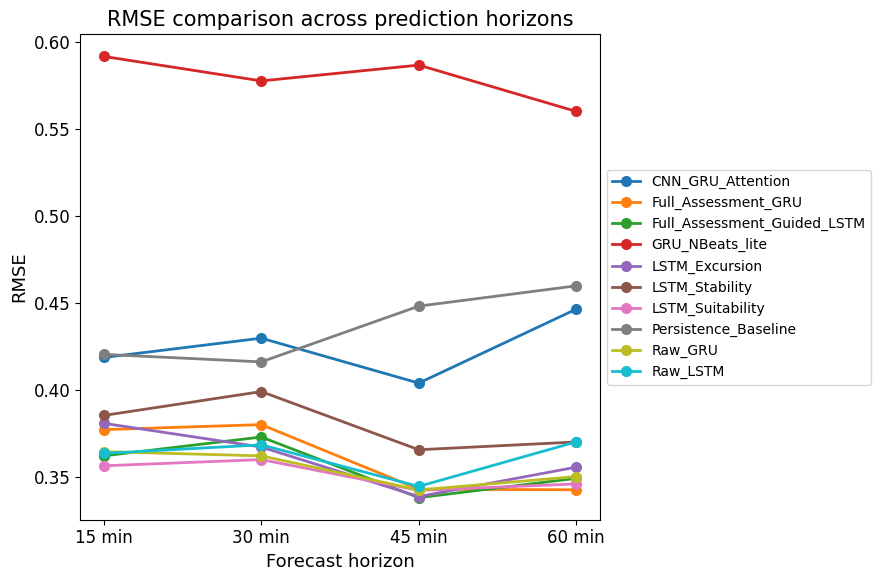

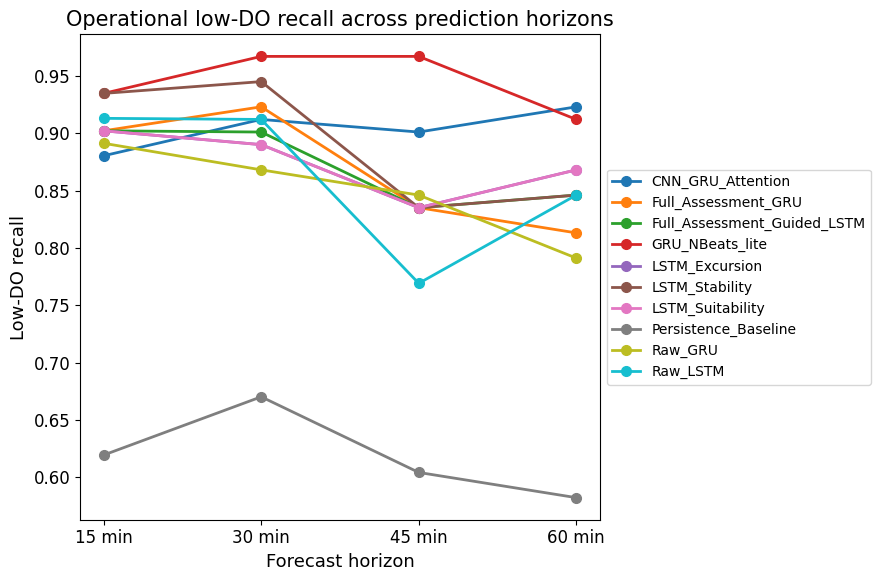

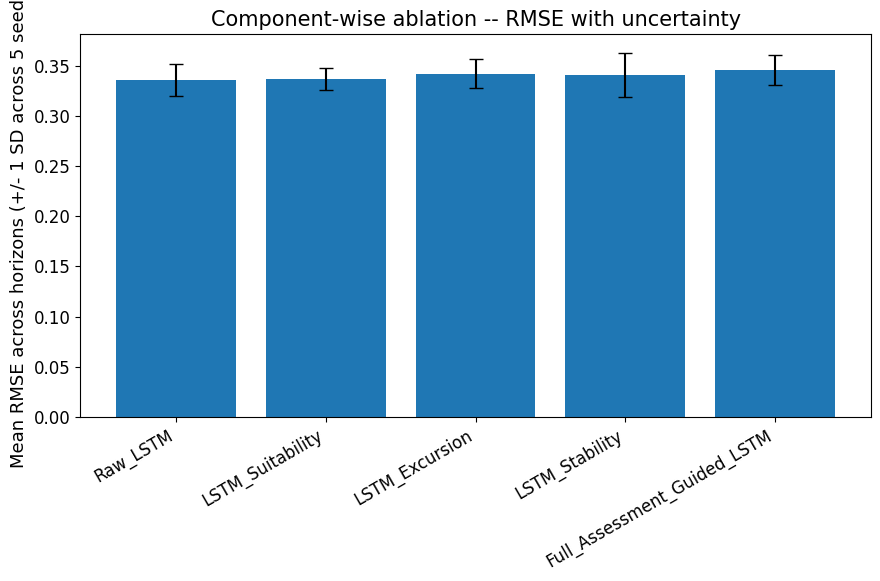

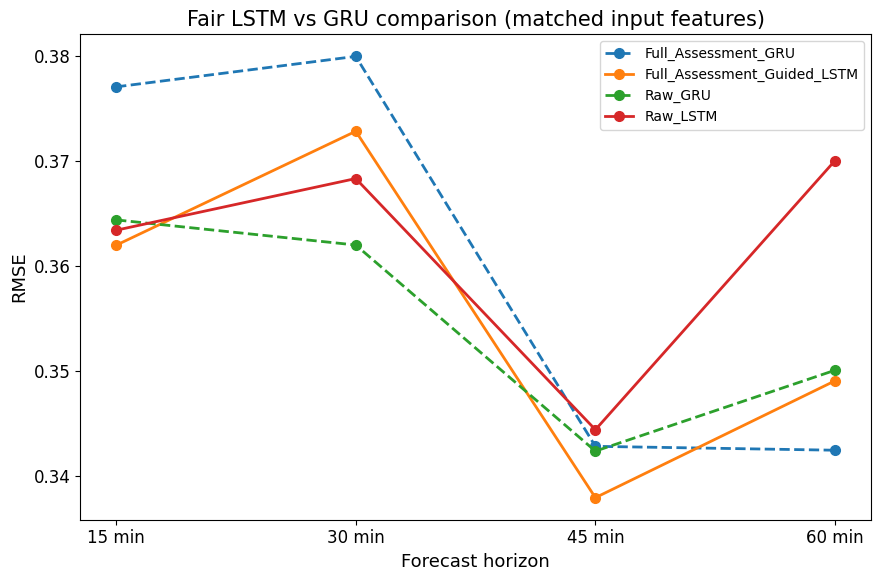

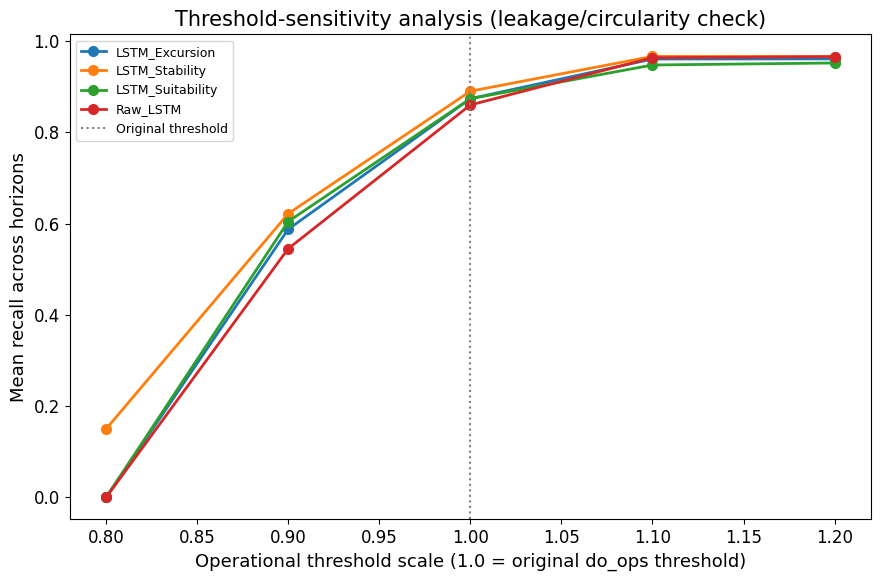

All figures saved with English labels to bab4_revised_results


In [ ]:
# =========================
# 14. Figures -- English labels, larger fonts, one panel per figure
#     (Reviewer 1 #6: figures were previously titled/labeled in Indonesian
#     and used small default matplotlib fonts; both are fixed here.)
# =========================
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'legend.fontsize': 11,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

primary = regression_df[(regression_df['fold'] == PRIMARY_FOLD) &
                         ((regression_df['seed'] == str(PRIMARY_SEED)) | (regression_df['seed'] == 'NA'))]
primary_low = lowdo_df[(lowdo_df['fold'] == PRIMARY_FOLD) &
                        ((lowdo_df['seed'] == str(PRIMARY_SEED)) | (lowdo_df['seed'] == 'NA'))]

# Figure: RMSE per horizon, all models (primary run)
plot_df = primary[primary['horizon'] != 'overall'].copy()
plt.figure(figsize=(9, 6))
for model_name, g in plot_df.groupby('scenario'):
    plt.plot(g['horizon'], g['RMSE'], marker='o', linewidth=2, markersize=7, label=model_name)
plt.xlabel('Forecast horizon')
plt.ylabel('RMSE')
plt.title('RMSE comparison across prediction horizons')
plt.legend(fontsize=10, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/fig_rmse_model_comparison.png', dpi=220, bbox_inches='tight')
plt.show()

# Figure: recall per horizon, all models (primary run)
plt.figure(figsize=(9, 6))
for model_name, g in primary_low.groupby('scenario'):
    plt.plot(g['horizon'], g['recall'], marker='o', linewidth=2, markersize=7, label=model_name)
plt.xlabel('Forecast horizon')
plt.ylabel('Low-DO recall')
plt.title('Operational low-DO recall across prediction horizons')
plt.legend(fontsize=10, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/fig_recall_lowdo_model_comparison.png', dpi=220, bbox_inches='tight')
plt.show()

# Figure: ablation overall RMSE with error bars across seeds (fold 0)
ablation_models = ['Raw_LSTM', 'LSTM_Suitability', 'LSTM_Excursion', 'LSTM_Stability', 'Full_Assessment_Guided_LSTM']
ab_overall = rmse_uncertainty.copy()
ab_overall = ab_overall[ab_overall['scenario'].isin(ablation_models)]
ab_overall_mean = ab_overall.groupby('scenario')['RMSE_mean'].mean().reindex(ablation_models)
ab_overall_sd = ab_overall.groupby('scenario')['RMSE_sd'].mean().reindex(ablation_models)
plt.figure(figsize=(9, 6))
plt.bar(ab_overall_mean.index, ab_overall_mean.values, yerr=ab_overall_sd.values, capsize=5)
plt.ylabel('Mean RMSE across horizons (+/- 1 SD across 5 seeds)')
plt.title('Component-wise ablation -- RMSE with uncertainty')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/fig_ablation_rmse_with_uncertainty.png', dpi=220, bbox_inches='tight')
plt.show()

# Figure: fair LSTM vs GRU comparison (Raw vs Raw, Full vs Full)
fair_pairs_df = primary[primary['scenario'].isin(['Raw_LSTM', 'Raw_GRU', 'Full_Assessment_Guided_LSTM', 'Full_Assessment_GRU']) &
                         (primary['horizon'] != 'overall')]
plt.figure(figsize=(9, 6))
for model_name, g in fair_pairs_df.groupby('scenario'):
    style = '--' if 'GRU' in model_name else '-'
    plt.plot(g['horizon'], g['RMSE'], style, marker='o', linewidth=2, markersize=7, label=model_name)
plt.xlabel('Forecast horizon')
plt.ylabel('RMSE')
plt.title('Fair LSTM vs GRU comparison (matched input features)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/fig_fair_lstm_vs_gru.png', dpi=220, bbox_inches='tight')
plt.show()

# Figure: recall vs threshold scale (threshold-sensitivity, Reviewer 2 #3)
ts = threshold_sensitivity_df[threshold_sensitivity_df['scenario'].isin(
    ['Raw_LSTM', 'LSTM_Suitability', 'LSTM_Excursion', 'LSTM_Stability'])]
plt.figure(figsize=(9, 6))
for model_name, g in ts.groupby('scenario'):
    g_mean = g.groupby('threshold_scale')['recall'].mean()
    plt.plot(g_mean.index, g_mean.values, marker='o', linewidth=2, markersize=7, label=model_name)
plt.axvline(1.0, color='gray', linestyle=':', label='Original threshold')
plt.xlabel('Operational threshold scale (1.0 = original do_ops threshold)')
plt.ylabel('Mean recall across horizons')
plt.title('Threshold-sensitivity analysis (leakage/circularity check)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/fig_threshold_sensitivity.png', dpi=220, bbox_inches='tight')
plt.show()

print('All figures saved with English labels to', RESULT_DIR)


## 15. Reproducibility Manifest, README, and Export (Reviewer 1 #9)

In [ ]:
# =========================
# 15. Reproducibility manifest, README, and final export
#     (Reviewer 1 #9: public GitHub-ready reproducibility package)
# =========================
import platform

environment_info = {
    'python_version': platform.python_version(),
    'tensorflow_version': tf.__version__,
    'numpy_version': np.__version__,
    'pandas_version': pd.__version__,
}
with open(f'{RESULT_DIR}/environment_info.json', 'w') as f:
    json.dump(environment_info, f, indent=2)

reproducibility_manifest = {
    'seeds_used_this_run': SEEDS,
    'quick_test_mode': QUICK_TEST_MODE,
    'window_steps': WINDOW,
    'forecast_horizons_steps': HORIZONS,
    'sampling_interval_minutes': INTERVAL_MINUTES,
    'n_blocks_for_walkforward': N_BLOCKS,
    'fold_specs': fold_specs,
    'fold_ids_run_this_session': FOLD_IDS,
    'multiseed_folds': MULTISEED_FOLDS,
    'selected_architecture': {'units': FINAL_UNITS, 'dropout': FINAL_DROPOUT, 'lr': 1e-3,
                               'dense_layer_units': 32, 'epochs_max': EPOCHS, 'batch_size': BATCH_SIZE,
                               'early_stopping_patience': PATIENCE},
    'feature_set_sizes': {k: len(v) for k, v in FEATURE_SETS.items()},
    'model_family_per_scenario': MODEL_FAMILY,
}
with open(f'{RESULT_DIR}/reproducibility_manifest.json', 'w') as f:
    json.dump(reproducibility_manifest, f, indent=2, default=str)

readme_text = f"""# BAB 4 Revised Results -- Reproducibility Package

Generated by the revised experiment notebook responding to IJIES Submission
No. 20265445 Major Revision (Reviewer 1 & Reviewer 2).

## Contents
- `processed_iot_dataset_with_features.csv` -- fully cleaned dataset with every
  engineered feature (suitability, excursion, stability, temporal).
- `feature_groups.json` / `feature_engineering_config.json` -- exact feature
  lists and explicit formulas for every engineered variable (Reviewer 2 #7).
- `pond_calendar_span.csv` -- calendar period actually covered by each pond
  (they were monitored SEQUENTIALLY, not in parallel -- see notebook Cell 0).
- `sequence_split_summary_all_folds.csv`, `fold{{N}}_test_timestamps.csv` --
  exact train/validation/test sequence counts and timestamps for fold 0
  (original 70/15/15 split) and folds 1-2 (rolling-origin walk-forward,
  Reviewer 2 #4).
- `hyperparameter_search_log.csv` -- the grid search over {{units, dropout}}
  and the selection rule used to fix the final architecture (Reviewer 2 #7).
- `leakage_audit_result.json` -- automated check that no feature uses
  future information (Reviewer 2 #3).
- `regression_metrics_all_runs.csv`, `low_do_metrics_all_runs.csv`,
  `decision_level_metrics_all_runs.csv` -- every model x fold x seed result.
- `rmse_uncertainty_fold0_multiseed.csv`, `recall_uncertainty_fold0_multiseed.csv`,
  `significance_tests_fold0_multiseed.csv` -- mean/SD/95% CI and paired
  Wilcoxon significance tests across {len(SEEDS)} seeds (Reviewer 2 #5).
- `rmse_across_rolling_origin_folds.csv` -- robustness of RMSE across
  temporally distinct test blocks (Reviewer 2 #4).
- `event_based_metrics_primary_run.csv` -- event-level (episode-level) low-DO
  detection, plus class-prevalence numbers in
  `assessment_excursion_do_summary_with_prevalence.csv` (Reviewer 2 #6).
- `threshold_sensitivity_primary_run.csv`, `threshold_free_auc_primary_run.csv`
  -- circularity / threshold-independence check (Reviewer 2 #3).
- `fig_*.png` -- all figures, English labels, larger fonts (Reviewer 1 #6).
- `reproducibility_manifest.json`, `environment_info.json` -- exact seeds,
  fold definitions, architecture, and library versions used.

## How to reproduce
1. Open the notebook this package was generated from in Google Colab.
2. Upload `iot_data.csv` when prompted.
3. Run all cells top to bottom with `QUICK_TEST_MODE = True` first to verify
   everything executes (~5-10 minutes).
4. Set `QUICK_TEST_MODE = False` and re-run for the full published numbers.

## Models compared (all under identical window/horizon/scaling protocol)
- Persistence baseline (no training)
- Raw_LSTM, Raw_GRU -- sensor + temporal features only (fair pair, Reviewer 2 #2)
- LSTM_Suitability, LSTM_Excursion, LSTM_Stability -- component-wise ablation
- Full_Assessment_Guided_LSTM, Full_Assessment_GRU -- full-feature pair (fair, Reviewer 2 #2)
- GRU_NBeats_lite, CNN_GRU_Attention -- reimplemented 2024+-style literature
  baselines, trained on the Raw feature set for a controlled comparison
  (Reviewer 1 #8, Reviewer 2 #1)

## Known scope limitation (documented, not hidden)
Multi-seed repetition (uncertainty quantification) is performed on fold 0
only; rolling-origin folds 1-2 currently run a single seed each due to
free-tier Colab compute constraints. Add fold ids to `MULTISEED_FOLDS` in
Cell 12 to extend multi-seed repetition to the rolling-origin folds if more
compute time is available.
"""
with open(f'{RESULT_DIR}/README.md', 'w') as f:
    f.write(readme_text)

zip_path = 'bab4_revised_results.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(RESULT_DIR):
        for file in files:
            path = os.path.join(root, file)
            zf.write(path, arcname=os.path.relpath(path, RESULT_DIR))

print('ZIP final dibuat:', zip_path)
print('Isi folder hasil:')
for f_ in sorted(os.listdir(RESULT_DIR)):
    print(' -', f_)

try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print('\\nDownload manual file:', zip_path)


ZIP final dibuat: bab4_revised_results.zip
Isi folder hasil:
 - README.md
 - assessment_excursion_do_summary_with_prevalence.csv
 - assessment_suitability_summary.csv
 - assessment_temporal_stability_summary.csv
 - data_readiness_summary.csv
 - decision_accuracy_uncertainty_fold0_multiseed.csv
 - decision_level_metrics_all_runs.csv
 - environment_info.json
 - event_based_metrics_primary_run.csv
 - feature_engineering_config.json
 - feature_groups.json
 - fig_ablation_rmse_with_uncertainty.png
 - fig_fair_lstm_vs_gru.png
 - fig_recall_lowdo_model_comparison.png
 - fig_rmse_model_comparison.png
 - fig_threshold_sensitivity.png
 - fold0_test_timestamps.csv
 - fold1_test_timestamps.csv
 - fold2_test_timestamps.csv
 - hyperparameter_search_log.csv
 - interval_summary.csv
 - leakage_audit_result.json
 - low_do_metrics_all_runs.csv
 - pond_calendar_span.csv
 - prediction_audit_CNN_GRU_Attention_fold0.csv
 - prediction_audit_Full_Assessment_GRU_fold0.csv
 - prediction_audit_Full_Assessment_Gui

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>